In [3]:
pip install networkx


Note: you may need to restart the kernel to use updated packages.


En ekonomik tur sırası: Ankara ➔ Keles ➔ Silopi ➔ Göynük ➔ Koyunağılı ➔ Dodurga ➔ Tavşanlı ➔ Çan ➔ Saray ➔ Soma ➔ Elbistan ➔ Ilgın ➔ Ankara
Toplam mesafe: 2398 km


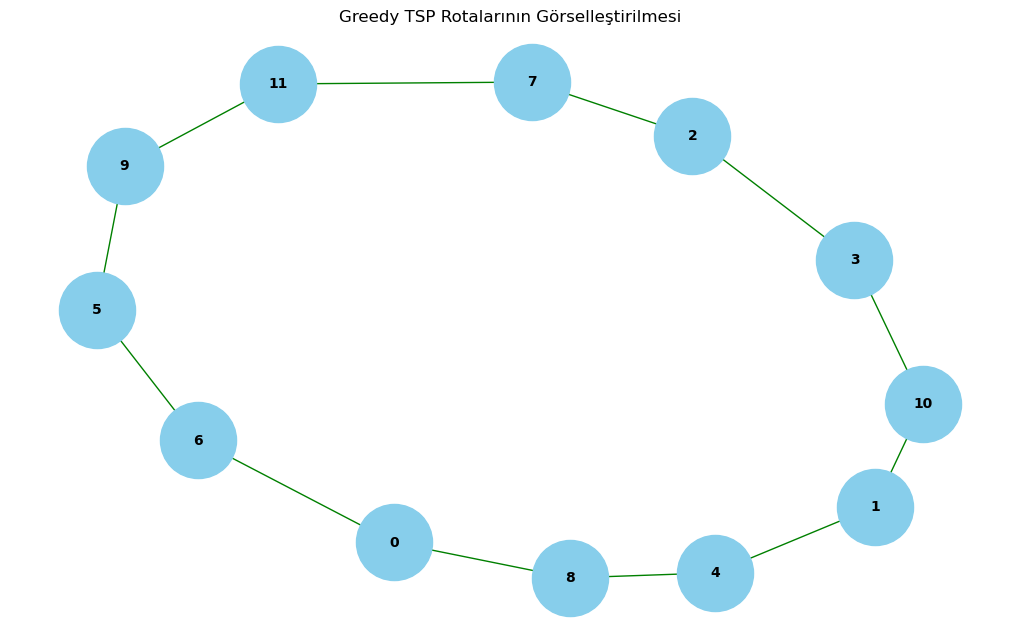

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Lokasyonlar
locations = [
    "Ankara", "Soma", "Tavşanlı", "Çan", "Elbistan", "Silopi",
    "Keles", "Dodurga", "Ilgın", "Göynük", "Saray", "Koyunağılı"
]

# Mesafeleri rastgele oluştur
np.random.seed(42)
distances = np.random.randint(100, 500, size=(len(locations), len(locations)))
np.fill_diagonal(distances, 0)

# Greedy TSP çözümü
def greedy_tsp(distances):
    n = len(distances)
    visited = [False] * n
    route = [0]  # Başlangıç noktası olarak Ankara'yı seçiyoruz
    visited[0] = True
    total_distance = 0
    
    for _ in range(n - 1):
        last_visited = route[-1]
        nearest_city = None
        min_distance = float('inf')
        
        # En yakın şehri bul
        for i in range(n):
            if not visited[i] and distances[last_visited][i] < min_distance:
                min_distance = distances[last_visited][i]
                nearest_city = i
        
        route.append(nearest_city)
        visited[nearest_city] = True
        total_distance += min_distance
    
    # Başlangıç noktasına dön
    total_distance += distances[route[-1]][route[0]]
    route.append(route[0])
    
    return route, total_distance

# Greedy algoritması ile çözümü bul
route, total_distance = greedy_tsp(distances)

# Şehirlerin sıralaması
route_names = [locations[i] for i in route]

# Sonuçları yazdır
print("En ekonomik tur sırası:", " ➔ ".join(route_names))
print(f"Toplam mesafe: {total_distance} km")

# Harita üzerinde görselleştirme
plt.figure(figsize=(10, 6))
G = nx.Graph()
for i, city in enumerate(locations):
    G.add_node(i, label=city)

for i in range(len(route) - 1):
    G.add_edge(route[i], route[i+1], weight=distances[route[i]][route[i+1]])

# Edge liste üzerinden görsel oluşturma
pos = nx.spring_layout(G)  # Yerleşim düzeni
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, font_weight='bold', edge_color='green')
plt.title("Greedy TSP Rotalarının Görselleştirilmesi")
plt.show()


In [5]:
import folium
import numpy as np
import webbrowser  # Tarayıcıda açmak için

# Lokasyonlar ve bunlara ait (örnek) koordinatlar
locations = [
    "Ankara", "Soma", "Tavşanlı", "Çan", "Elbistan", "Silopi",
    "Keles", "Dodurga", "Ilgın", "Göynük", "Saray", "Koyunağılı"
]

# Koordinatlar (örnek olarak yerel koordinatlar veriliyor)
coordinates = {
    "Ankara": (39.9334, 32.8597),
    "Soma": (39.0000, 27.0000),
    "Tavşanlı": (39.1400, 30.1800),
    "Çan": (40.1333, 26.4170),
    "Elbistan": (37.3995, 37.1944),
    "Silopi": (37.5708, 42.0408),
    "Keles": (40.0645, 28.8423),
    "Dodurga": (40.0450, 29.3700),
    "Ilgın": (38.2385, 31.4079),
    "Göynük": (40.3892, 31.5206),
    "Saray": (41.2414, 27.0702),
    "Koyunağılı": (40.5000, 29.6500),
}

# Mesafeler için rastgele bir matris oluştur (gerçek mesafeler yerine)
np.random.seed(42)
distances = np.random.randint(100, 500, size=(len(locations), len(locations)))
np.fill_diagonal(distances, 0)

# Greedy TSP çözümü
def greedy_tsp(distances):
    n = len(distances)
    visited = [False] * n
    route = [0]  # Başlangıç noktası olarak Ankara'yı seçiyoruz
    visited[0] = True
    total_distance = 0
    
    for _ in range(n - 1):
        last_visited = route[-1]
        nearest_city = None
        min_distance = float('inf')
        
        # En yakın şehri bul
        for i in range(n):
            if not visited[i] and distances[last_visited][i] < min_distance:
                min_distance = distances[last_visited][i]
                nearest_city = i
        
        route.append(nearest_city)
        visited[nearest_city] = True
        total_distance += min_distance
    
    # Başlangıç noktasına dön
    total_distance += distances[route[-1]][route[0]]
    route.append(route[0])
    
    return route, total_distance

# Greedy algoritması ile çözümü bul
route, total_distance = greedy_tsp(distances)

# Şehir isimlerini rotaya göre sıralama
route_names = [locations[i] for i in route]

# Harita üzerinde görselleştirme için folium haritası oluştur
m = folium.Map(location=coordinates["Ankara"], zoom_start=6, control_scale=True)

# Şehirlerin koordinatları üzerinde markerlar ekleyelim
for i, city in enumerate(locations):
    folium.Marker(
        location=coordinates[city],
        popup=f"{city} - {i+1}. sırada",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m)

# Rotayı çizmek için şehirler arasında çizgiler ekle
for i in range(len(route) - 1):
    start_city = route_names[i]
    end_city = route_names[i+1]
    
    folium.PolyLine(
        locations=[coordinates[start_city], coordinates[end_city]],
        color="red",
        weight=2.5,
        opacity=1
    ).add_to(m)

# Haritayı kaydedelim
map_filename = "tsp_route_map_with_order.html"
m.save(map_filename)

# Haritayı otomatik olarak tarayıcıda aç
webbrowser.open(map_filename)

# Rotadaki şehirlerin sıralaması ve mesafeyi yazdıralım
print("Ziyaret sırasına göre şehirler:")
for idx, city in enumerate(route_names):
    print(f"{idx + 1}. {city}")

print(f"\nToplam mesafe: {total_distance} km")

print(f"\nHarita '{map_filename}' olarak kaydedildi ve otomatik olarak açıldı.")


Ziyaret sırasına göre şehirler:
1. Ankara
2. Keles
3. Silopi
4. Göynük
5. Koyunağılı
6. Dodurga
7. Tavşanlı
8. Çan
9. Saray
10. Soma
11. Elbistan
12. Ilgın
13. Ankara

Toplam mesafe: 2398 km

Harita 'tsp_route_map_with_order.html' olarak kaydedildi ve otomatik olarak açıldı.
